<a href="https://colab.research.google.com/github/CarlosfcPinheiro/pibic-api-llm-integration/blob/main/pibic_grpc_service_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teste de Requisições para LLMs utilizando Padrão gRPC (Google Remote Procedure Call)

O objetivo principal é testar e avaliar o desempenho e a eficiência de custo de requisições para uma API Gateway de LLMs utilizando o padrão **gRPC**, comparando-o com os padrões REST e Assíncrono (Filas) analisados anteriormente no projeto.

## Código e Estrutura
Para a análise experimental, são utilizados **8 prompts diferentes**, abrangendo diversas extensões e domínios de texto para explorar a capacidade de sumarização. O script de teste simula a carga de trabalho através de uma bateria de **30 iterações por prompt** para o modelo selecionado, totalizando 240 execuções por bateria de teste.

Diferente do padrão de filas assíncronas, este teste utiliza **chamadas unárias síncronas sobre HTTP/2**, explorando a serialização binária do **Protocol Buffers (Protobuf)** para reduzir o overhead de payload e latência de comunicação.

Os testes são executados de forma individualizada ou sequencial para os **4 modelos especializados**:
- `facebook/bart-large-cnn`
- `google/pegasus-cnn_dailymail`
- `knkarthick/MEETING_SUMMARY`
- `google/pegasus-xsum`

**Nota Metodológica:** A execução ocorre em ambiente de *loopback* (localhost) dentro do Google Colab. Esta decisão visa isolar a latência intrínseca do protocolo e o tempo de processamento da LLM, eliminando variáveis externas de rede (instabilidades de internet ou limitações de túneis TCP como ngrok) que poderiam comprometer a precisão estatística e a isonomia da comparação entre gRPC e REST.

## Padrões e Bibliotecas
O padrão utilizado é o **gRPC Unary RPC**, caracterizado por conexões persistentes e transporte eficiente de dados. O servidor (Gateway) e o Cliente (script de teste) coexistem no mesmo ambiente de execução através de processamento em *threads* separadas.

As principais bibliotecas utilizadas são:
- `grpcio` & `grpcio-tools`: Core do framework gRPC e compilador de interfaces `.proto`.
- `transformers (AutoTokenizer)`: Utilizada no Server-side para a contabilização real e precisa de tokens de entrada e saída.
- `pandas`: Manipulação de DataFrames e exportação de dados brutos para arquivos `.csv`.
- `time`: Medição de latência utilizando `perf_counter()` para precisão em nanossegundos.
- `logging`: Rastreamento sistemático da execução e captura de erros de inferência.

## Métricas Analisadas
Para garantir a compatibilidade com a **Atividade 6** (Avaliação de resultados) do plano de trabalho, as seguintes métricas são coletadas e armazenadas:

- **Latência de Resposta:** Tempo total da requisição (Média, Mínimo, Máximo).
- **Estabilidade Experimental:** Desvio Padrão e Coeficiente de Variação (CV%).
- **Análise de Cauda:** Percentis 95% (P95) e 99% (P99).
- **Eficiência de Dados:** Contagem real de **Tokens de Entrada (t_in)** e **Tokens de Saída (t_out)**, utilizando o tokenizador específico de cada modelo.
- **Custo Estimado:** Cálculo financeiro baseado na métrica de **US$ 0,0006 por 1.000 tokens** (soma de entrada e saída).
- **Vazão (Throughput):** Quantidade de requisições processadas por segundo (req/s).

> Todas as métricas de tempo utilizam o segundo (s) como unidade base, e as métricas de custo utilizam o Dólar Americano (USD).

In [ ]:
# Instalação de dependências ==========================
!pip install grpcio grpcio-tools fastapi uvicorn nest-asyncio

In [ ]:
# Gerar o arquivo .proto e compilar (O mesmo conteúdo usado em ambos server-side e client-side) ==========================
with open("summarizer.proto", "w") as f:
  f.write("""
  syntax = "proto3";
  service LLMGateway {
    rpc Summarize (SummarizeRequest) returns (SummarizeResponse) {}
  }
  message SummarizeRequest {
    string text = 1;
    string model_key = 2;
  }
  message SummarizeResponse {
    string summary = 1;
    int32 tokens_in = 2;
    int32 tokens_out = 3;
  }
  """)

# Compilar .proto em stubs
!python -m grpc_tools.protoc -I. --python_out=. --grpc_python_out=. summarizer.proto

import summarizer_pb2
import summarizer_pb2_grpc

# Server-side

In [ ]:
# Configuração de variáveis globais ==========================
import grpc
from concurrent import futures
import threading
import time
import pandas as pd
import requests
import nest_asyncio
from google.colab import userdata

# dict com todos parâmetros de rota acessíveis para cada endpoint de modelo no HF
MODELS_HF_ROUTES = {
  "facebook_bart_large_cnn": "https://router.huggingface.co/hf-inference/models/facebook/bart-large-cnn",
  "google_pegasus_cnn_dailymail": "https://router.huggingface.co/hf-inference/models/google/pegasus-cnn_dailymail",
  "knkarthick_MEETING_SUMMARY": "https://router.huggingface.co/hf-inference/models/knkarthick/MEETING_SUMMARY",
  "google_pegasus_xsum": "https://router.huggingface.co/hf-inference/models/google/pegasus-xsum"
}

HUGGINGFACE_TOKEN = userdata.get('HUGGINGFACE_TOKEN')

In [ ]:
# Função para lógica de inferência ==========================
def call_huggingface_api(model_key, text):
  """Função única de processamento para garantir igualdade nos testes"""
  url = MODELS_HF_ROUTES[model_key]
  headers = {"Authorization": f"Bearer {HUGGINGFACE_TOKEN}"}
  response = requests.post(url, headers=headers, json={"inputs": text})
  return response.json()

In [ ]:
# Declaração dos tokenizers ==========================
from transformers import AutoTokenizer

# mapeamento para o tokenizer de cada modelo
TOKENIZER_MAP = {
    "facebook_bart_large_cnn": "facebook/bart-large-cnn",
    "google_pegasus_cnn_dailymail": "google/pegasus-cnn_dailymail",
    "knkarthick_MEETING_SUMMARY": "knkarthick/MEETING_SUMMARY",
    "google_pegasus_xsum": "google/pegasus-xsum"
}

# dict para cache de tokenizers
loaded_tokenizers = {}

# função para recuperar o tokenizer (recupera do loaded_tokenizer caso já exista)
def get_tokenizer(model_key, prompt):
  if model_key not in loaded_tokenizers:
    repo_id = TOKENIZER_MAP[model_key]
    loaded_tokenizers[model_key] = AutoTokenizer.from_pretrained(repo_id)
  tokenizer = loaded_tokenizers[model_key]
  # retorna a quantidade de tokens da lista
  return len(tokenizer.encode(prompt))

In [ ]:
# Implementação da classe Servicer ==========================
class LLMGatewayService(summarizer_pb2_grpc.LLMGatewayServicer):
  def Summarize(self, req, context):
    # lógica de processamento e chamada da API
    result = call_huggingface_api(req.model_key, req.text)
    summary_text = result[0]["summary_text"]

    # contabilização dos tokens
    t_in = get_tokenizer(req.model_key, req.text)
    t_out = get_tokenizer(req.model_key, summary_text)

    return summarizer_pb2.SummarizeResponse(
        summary=summary_text,
        tokens_in=t_in,
        tokens_out=t_out
    )

# função para iniciar servidor gRPC
def serve_grpc():
  server = grpc.server(futures.ThreadPoolExecutor(max_workers=10))
  summarizer_pb2_grpc.add_LLMGatewayServicer_to_server(LLMGatewayService(), server)
  server.add_insecure_port('[::]:50051')
  server.start()
  print("Servidor gRPC rodando localmente na porta 50051...")
  server.wait_for_termination()

In [ ]:
# Iniciar servidor em thread separada ==========================
grpc_thread = threading.Thread(target=serve_grpc, daemon=True)
grpc_thread.start()

# Client-side

In [ ]:
# Variáveis globais do client ==========================
TESTS_PER_PROMPT = 30
BASE_PRICE_PER_1K_TOKENS = 0.0006
CURRENT_MODEL = "facebook_bart_large_cnn"
OUTPUT_CSV_FILE = f"raw_data_requests_{CURRENT_MODEL}.csv"
PROMPTS = [
    """Solar energy is one of the most promising renewable sources for the planet’s future. With concerns about climate change and the need to reduce fossil fuel dependence, many countries are investing in clean technologies. Brazil has one of the largest solar potentials, especially in the Northeast and Midwest, where radiation is high year-round. The installation of solar panels in homes and businesses has grown, driven by incentives and lower equipment costs. Distributed generation allows consumers to also produce energy, helping decentralize the electricity system. Challenges remain, such as infrastructure, storage, and stronger public policies, but with technology and social engagement, solar energy is set to play an increasingly important role in Brazil’s energy matrix.""",

    """The city of Ouro Preto, located in the state of Minas Gerais, is one of the greatest symbols of Brazilian colonial architecture and history. Founded in the 17th century during the gold rush, it quickly became one of the main economic centers of the Portuguese colony, attracting thousands of people in search of wealth. Its stone streets, steep slopes, and preserved buildings reveal a past marked by opulence, religiosity, and resistance. Ouro Preto is home to some of the most impressive baroque churches in Brazil, such as the Church of Saint Francis of Assisi, designed by Aleijadinho and decorated with works by Mestre Ataíde. The city was also the stage for important events of the Inconfidência Mineira, a movement that sought Brazil’s independence from Portugal. Today, the city is recognized as a UNESCO World Heritage Site, attracting tourists interested in history, art, and culture. In addition to its historical value, Ouro Preto has a vibrant university life thanks to the Federal University of Ouro Preto (UFOP) and hosts various festivals of art, music, and cinema throughout the year. This combination of tradition and youth makes the city a unique place where past and present coexist in harmony.""",

    """Artificial intelligence (AI) is one of the most transformative technologies of the 21st century. It impacts medicine, education, industry, and commerce, improving efficiency and user experience. At the same time, AI raises ethical concerns about data use, bias, and its impact on jobs. Governments and society must ensure its benefits are distributed fairly and responsibly.""",

    """Classical music, although it emerged centuries ago, continues to influence contemporary composers. Works by Beethoven, Mozart, and Bach are studied in conservatories and reinterpreted in different musical styles. This tradition shows how art can transcend generations and reinvent itself.""",

    """The history of the internet began in the 1960s with military projects in the United States, evolving into academic networks and later into commercial use. Today, the internet connects billions of people in real time, transforming the way we work, study, and interact. Digital platforms enable instant communication, e-commerce, and unlimited access to information. However, problems also arise, such as fake news, cybercrime, and technological dependence. The future of the internet depends on balanced regulations, continuous innovation, and digital education so that its benefits can be enjoyed safely and inclusively.""",

    """Coffee is one of the most consumed beverages in the world and is part of Brazilian culture.""",

    """The Olympic Games are more than just a sporting event; they represent a celebration of unity, diversity, and human achievement. Athletes from around the world gather to compete at the highest level, showcasing not only physical skill but also resilience and determination. The Games have evolved over time, incorporating new disciplines and promoting values such as fair play and respect. Beyond the competitions, the Olympics foster cultural exchange, allowing nations to share traditions and build mutual understanding. Despite challenges such as political tensions and financial costs, the spirit of the Olympics continues to inspire millions, proving that sport can be a powerful force for peace and cooperation.""",

    """The Renaissance was a period of profound cultural, artistic, and scientific transformation in Europe between the 14th and 17th centuries. It marked the rediscovery of classical knowledge and the flourishing of human creativity. Artists like Leonardo da Vinci and Michelangelo produced masterpieces that continue to inspire admiration today, while scientists such as Galileo challenged traditional views of the universe. The invention of the printing press by Gutenberg revolutionized the spread of ideas, making books more accessible and fueling intellectual debates."""
]

In [ ]:
# Configuração do Cliente gRPC ==========================
channel = grpc.insecure_channel('localhost:50051')
stub = summarizer_pb2_grpc.LLMGatewayStub(channel)

In [ ]:
# Configuração de logger ==========================
import logging
import sys

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s: %(message)s",
    handlers=[
        logging.FileHandler("grpc_tests.log"),
        logging.StreamHandler(sys.stdout)
    ],
    force=True
)
logger = logging.getLogger()

In [ ]:
# Função principal de execução dos testes ==========================
def run_experiment(prompts, model_key, iterations=TESTS_PER_PROMPT):
    all_results = []
    pid_list = list(range(1, len(prompts) + 1))

    for p_idx, p_text in enumerate(prompts):
        pid = p_idx + 1
        logger.info(f"Teste de inferência - Modelo: {model_key} | Prompt: {pid}")

        for i in range(iterations):
            req_id = i + 1
            try:
                # requisição Protobuf conforme definido no seu .proto
                req = summarizer_pb2.SummarizeRequest(text=p_text, model_key=model_key)

                # medição de latência com alta precisão
                start = time.perf_counter()
                res = stub.Summarize(req)
                end = time.perf_counter()

                total_time = round(end - start, 4)

                # extração de métricas de tokens
                t_in = res.tokens_in
                t_out = res.tokens_out

                # cálculo de custo (US$ 0,0006 por 1k tokens)
                custo_req = round(((t_in + t_out) / 1000) * BASE_PRICE_PER_1K_TOKENS, 6)

                # armazenamento dos dados
                all_results.append({
                    "modelo": model_key,
                    "prompt_id": pid,
                    "req_id": req_id,
                    "prompt_entrada": p_text,
                    "saida_resposta": res.summary,
                    "tokens_in": t_in,
                    "tokens_out": t_out,
                    "custo_usd": custo_req,
                    "tempo_s": total_time
                })

            except Exception as e:
                logger.error(f"Erro no Modelo {model_key} | Prompt {pid} | Req {req_id}: {e}")
                print(f"  --> Erro na Req {req_id}: {e}")
                continue

    return pd.DataFrame(all_results)

## Testes

In [ ]:
# Execução dos testes ==========================
# execução individual por modelo (para rodar outro, basta mudar a variável CURRENT_MODEL e executar a célula novamente)
df_modelo_atual = run_experiment(PROMPTS, CURRENT_MODEL)

# salvar o arquivo com nome específico do modelo
filename = f"raw/raw_data_grpc_{CURRENT_MODEL}.csv"
df_modelo_atual.to_csv(filename, index=False)

print(f"\nTestes concluídos para o modelo {CURRENT_MODEL}. Arquivo salvo: {filename}")

2026-05-08 02:16:24,758: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


2026-05-08 02:16:33,658: HTTP Request: HEAD https://huggingface.co/google/pegasus-xsum/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-08 02:16:33,684: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/pegasus-xsum/8d8ffc158a3bee9fbb03afacdfc347c823c5ec8b/config.json "HTTP/1.1 200 OK"
2026-05-08 02:16:33,716: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google/pegasus-xsum/8d8ffc158a3bee9fbb03afacdfc347c823c5ec8b/config.json "HTTP/1.1 200 OK"


config.json: 0.00B [00:00, ?B/s]

2026-05-08 02:16:33,856: HTTP Request: HEAD https://huggingface.co/google/pegasus-xsum/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"


...

2026-05-08 02:16:34,436: HTTP Request: HEAD https://huggingface.co/google/pegasus-xsum/resolve/main/tokenizer.json "HTTP/1.1 307 Temporary Redirect"
2026-05-08 02:16:34,458: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/pegasus-xsum/8d8ffc158a3bee9fbb03afacdfc347c823c5ec8b/tokenizer.json "HTTP/1.1 200 OK"
2026-05-08 02:16:34,489: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google/pegasus-xsum/8d8ffc158a3bee9fbb03afacdfc347c823c5ec8b/tokenizer.json "HTTP/1.1 200 OK"


tokenizer.json: 0.00B [00:00, ?B/s]

2026-05-08 02:16:34,593: HTTP Request: HEAD https://huggingface.co/google/pegasus-xsum/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
2026-05-08 02:16:34,647: HTTP Request: HEAD https://huggingface.co/google/pegasus-xsum/resolve/main/special_tokens_map.json "HTTP/1.1 307 Temporary Redirect"
2026-05-08 02:16:34,666: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/pegasus-xsum/8d8ffc158a3bee9fbb03afacdfc347c823c5ec8b/special_tokens_map.json "HTTP/1.1 200 OK"
2026-05-08 02:16:34,687: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google/pegasus-xsum/8d8ffc158a3bee9fbb03afacdfc347c823c5ec8b/special_tokens_map.json "HTTP/1.1 200 OK"


special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

2026-05-08 02:16:34,764: HTTP Request: HEAD https://huggingface.co/google/pegasus-xsum/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-05-08 02:17:24,159: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 2
2026-05-08 02:18:57,634: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 3
2026-05-08 02:19:53,807: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 4
2026-05-08 02:20:45,566: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 5
2026-05-08 02:21:36,646: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 6
2026-05-08 02:22:15,191: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 7
2026-05-08 02:23:00,931: Teste de inferência - Modelo: google_pegasus_xsum | Prompt: 8

Testes concluídos para o modelo google_pegasus_xsum. Arquivo salvo: raw/raw_data_grpc_google_pegasus_xsum.csv


# Análise

In [ ]:
# Carregamento do csv (modelo selecionado) ==========================
from google.colab import data_table
import pandas as pd
import numpy as np

# facebook_bart_large_cnn | google_pegasus_cnn_dailymail | knkarthick_MEETING_SUMMARY | google_pegasus_xsum
CURRENT_MODEL = "google_pegasus_xsum"

filename = f"raw/raw_data_grpc_{CURRENT_MODEL}.csv"
df_raw = pd.read_csv(filename)

In [ ]:
# Função de processamento das métricas ==========================
def analyze_metrics(df):
    # Agrupamento e agregação das métricas base
    analysis = df.groupby('prompt_id').agg({
        'tempo_s': ['mean', 'min', 'max', 'std', 'sum', 'count'],
        'tokens_in': 'sum',
        'custo_usd': ['mean', 'sum']
    })

    analysis.columns = ['avg', 'min_time', 'max_time', 'std', 'total_time', 'req_per_prompt', 'tokens_input', 'avg_cost', 'total_cost']
    analysis = analysis.reset_index().rename(columns={'prompt_id': 'pid'})

    # Cálculo do Coeficiente de Variação (CV%)
    analysis['coef_var'] = (analysis['std'] / analysis['avg']) * 100

    # Cálculo do Throughput (Vazão)
    analysis['throughput'] = analysis['req_per_prompt'] / analysis['total_time']

    # Cálculo de Percentis
    p95 = df.groupby('prompt_id')['tempo_s'].quantile(0.95).rename('p95')
    p99 = df.groupby('prompt_id')['tempo_s'].quantile(0.99).rename('p99')

    # Merge dos percentis na tabela final
    analysis = analysis.merge(p95, left_on='pid', right_index=True)
    analysis = analysis.merge(p99, left_on='pid', right_index=True)

    cols_order = [
        'pid', 'tokens_input', 'min_time', 'max_time', 'total_time',
        'throughput', 'req_per_prompt', 'avg', 'std', 'coef_var',
        'avg_cost', 'total_cost', 'p95', 'p99'
    ]

    return analysis[cols_order].round(4)

In [ ]:
# Execução, preview e salvamento (modelo selecionado) ==========================
df_metrics = analyze_metrics(df_raw)
df_metrics = df_metrics.round(4)

print(f"Análise Experimental Concluída - Modelo: {CURRENT_MODEL}")
display(df_metrics)

output_metrics_file = f"metrics/metrics_data_grpc_{CURRENT_MODEL}.csv"
df_metrics.to_csv(output_metrics_file, index=False)
print(f"\nResultados salvos em: {output_metrics_file}")

Análise Experimental Concluída - Modelo: google_pegasus_xsum


,pid,tokens_input,min_time,max_time,total_time,throughput,req_per_prompt,avg,std,coef_var,avg_cost,total_cost,p95,p99
0,1,4200,1.2339,12.1392,59.3981,0.5051,30,1.9799,1.9476,98.3681,0.0001,0.0028,2.6428,9.5695
1,2,7620,2.3529,4.5892,93.4741,0.3209,30,3.1158,0.5200,16.6885,0.0002,0.0051,4.1627,4.5042
2,3,2100,1.4884,5.0084,56.1712,0.5341,30,1.8724,0.8410,44.9141,0.0001,0.0018,3.5619,4.9629
3,4,1440,1.2919,2.3238,51.7580,0.5796,30,1.7253,0.2352,13.6350,0.0000,0.0014,2.0782,2.2531
4,5,3390,1.4243,1.9362,51.0786,0.5873,30,1.7026,0.1607,9.4408,0.0001,0.0025,1.9104,1.9332
5,6,570,1.0083,1.9939,38.5441,0.7783,30,1.2848,0.1667,12.9710,0.0000,0.0006,1.3974,1.8244
6,7,3660,1.2039,1.7124,45.7385,0.6559,30,1.5246,0.1447,9.4893,0.0001,0.0026,1.6610,1.6987
7,8,2760,1.6344,2.3505,59.8591,0.5012,30,1.9953,0.2037,10.2102,0.0001,0.0021,2.2350,2.3232



Resultados salvos em: metrics/metrics_data_grpc_google_pegasus_xsum.csv


In [ ]:
# Compilação dos csv de métricas ==========================
import glob
import os
import pandas as pd

path = "."
# Ajuste de caminho para encontrar os arquivos na raiz ou na pasta metrics
all_files = glob.glob("metrics_data_grpc_*.csv") + glob.glob("metrics/metrics_data_grpc_*.csv")
raw_files = glob.glob("raw_data_grpc_*.csv")

print(f"Arquivos de métricas encontrados: {len(all_files)}")

# Criar um mapeamento de tokens_out médio a partir dos dados brutos
out_counts = {}
if raw_files:
    df_raw_all = pd.concat([pd.read_csv(f) for f in raw_files], ignore_index=True)
    # Agrupa por modelo e prompt para ter a média exata de tokens_out
    out_counts = df_raw_all.groupby(['modelo', 'prompt_id'])['tokens_out'].mean().to_dict()

dfs = []
for file in all_files:
    df_temp = pd.read_csv(file)
    model_name = os.path.basename(file).replace("metrics_data_grpc_", "").replace(".csv", "")
    df_temp["modelo"] = model_name

    # Alinha 'pid' com 'prompt_id' e insere a coluna faltante 'tokens_output'
    if 'pid' in df_temp.columns:
        df_temp['tokens_output'] = df_temp.apply(lambda x: out_counts.get((model_name, x['pid']), 0), axis=1)

    dfs.append(df_temp)

if dfs:
    final_df = pd.concat(dfs, ignore_index=True)
    output_filename = "models_metrics_data_grpc_final.csv"
    final_df.to_csv(output_filename, index=False)
    print(f"Consolidação concluída! Arquivo gerado: {output_filename}")
    display(final_df.head())
else:
    print("Nenhum arquivo de métricas gRPC foi encontrado.")

Arquivos de métricas encontrados: 4
Consolidação concluída! Arquivo gerado: models_metrics_data_grpc_final.csv


,pid,tokens_input,min_time,max_time,total_time,throughput,req_per_prompt,avg,std,coef_var,avg_cost,total_cost,p95,p99,modelo,tokens_output
0,1,4200,2.9989,13.5137,118.5094,0.2531,30,3.9503,1.8371,46.5044,0.0001,0.0032,4.2747,10.8434,google_pegasus_cnn_dailymail,0
1,2,7620,2.6278,3.7626,90.4928,0.3315,30,3.0164,0.3523,11.6805,0.0002,0.0056,3.5977,3.7247,google_pegasus_cnn_dailymail,0
2,3,2100,3.0651,4.7018,108.0968,0.2775,30,3.6032,0.3851,10.6889,0.0001,0.0023,4.3564,4.6041,google_pegasus_cnn_dailymail,0
3,4,1440,1.8740,2.6936,65.4878,0.4581,30,2.1829,0.2403,11.0079,0.0000,0.0015,2.5900,2.6857,google_pegasus_cnn_dailymail,0
4,5,3390,3.0803,4.0902,102.3990,0.2930,30,3.4133,0.2980,8.7293,0.0001,0.0031,3.9992,4.0864,google_pegasus_cnn_dailymail,0


# Visualização Gráfica

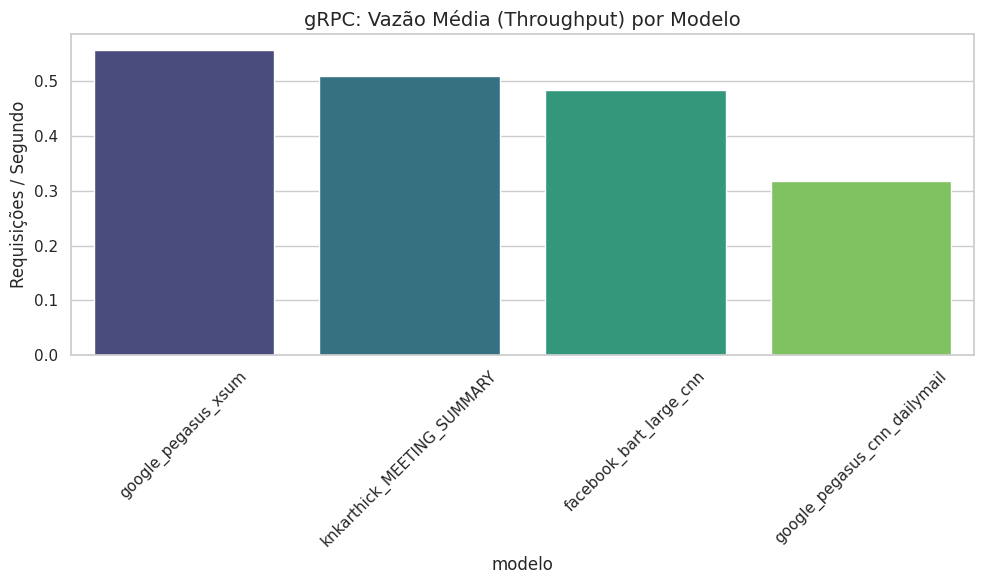

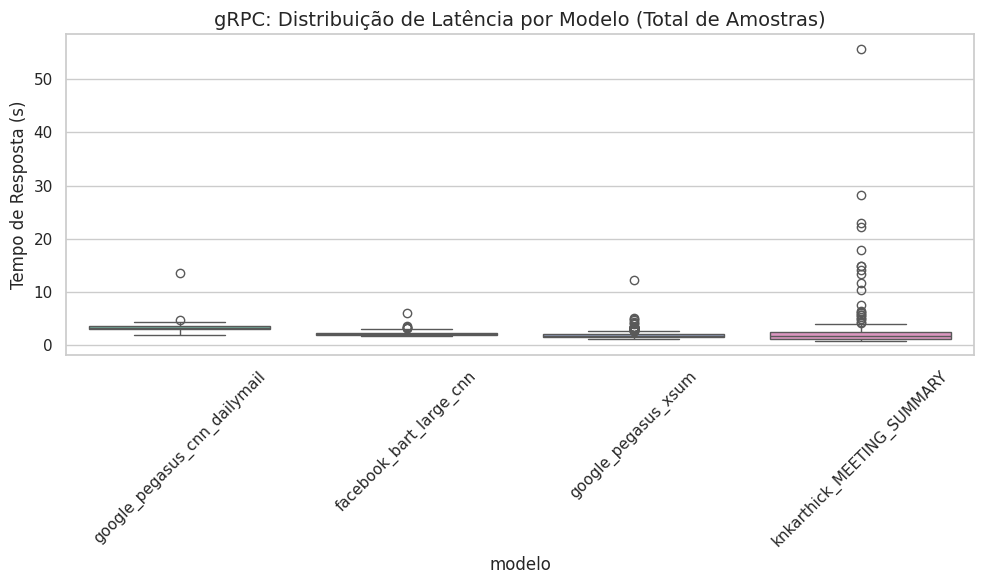

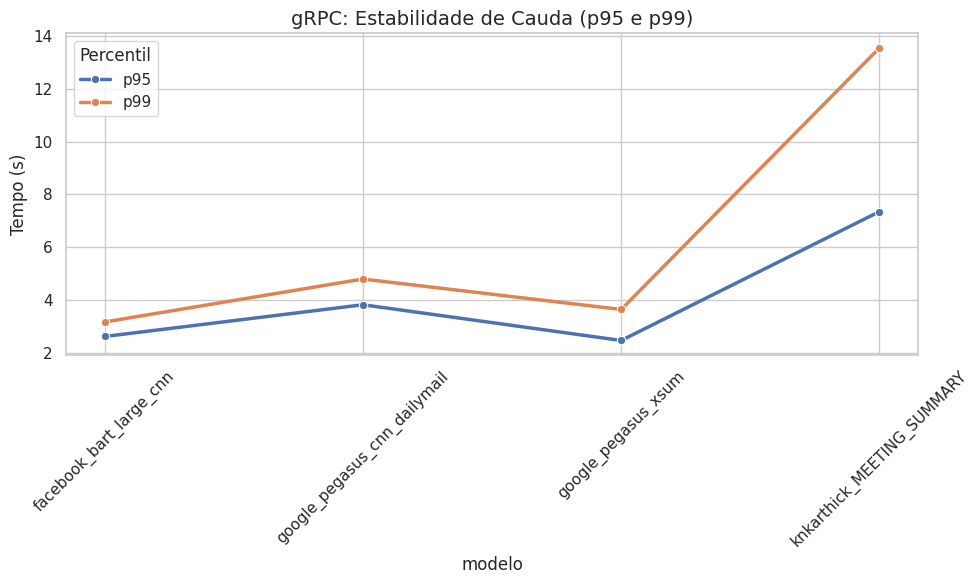

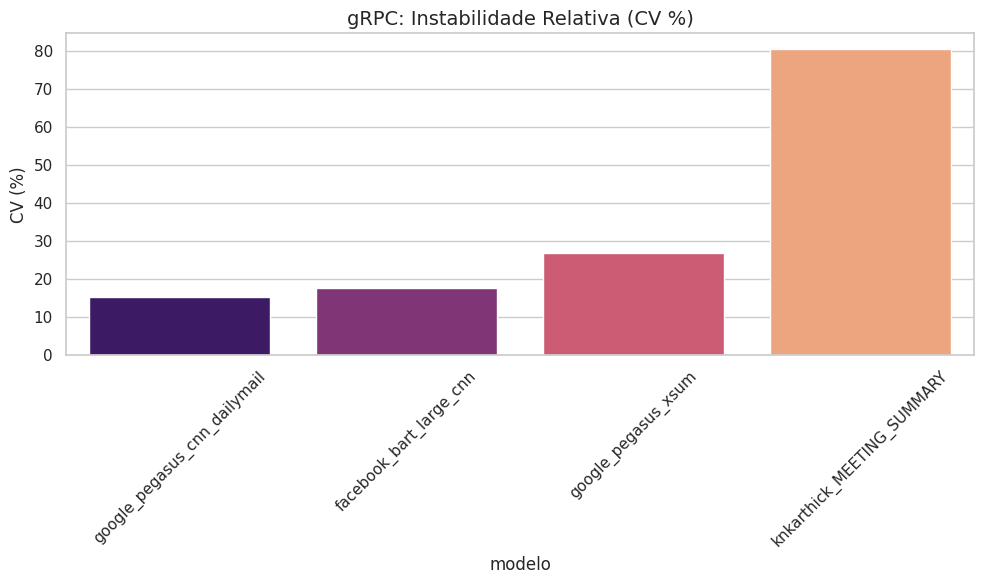

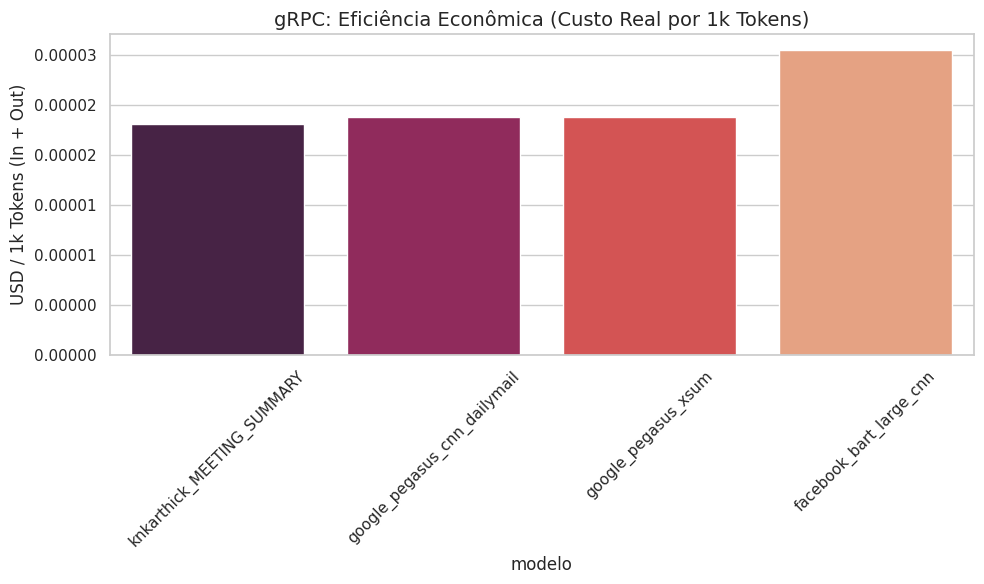

In [ ]:
# Geração dos gráficos ==========================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models_metrics_filename = "models_metrics_data_grpc_final.csv"

# Configuração de estilo
sns.set_theme(style="whitegrid")
df = pd.read_csv(models_metrics_filename)

raw_data = glob.glob("raw/raw_data_grpc_*.csv")
df_raw_grpc = pd.concat([pd.read_csv(f) for f in raw_data], ignore_index=True)

# Vazão (Throughput)
plt.figure(figsize=(10, 6))
df_tp = df.groupby("modelo")["throughput"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=df_tp, x="modelo", y="throughput", hue="modelo", palette="viridis")
plt.title("gRPC: Vazão Média (Throughput) por Modelo", fontsize=14)
plt.ylabel("Requisições / Segundo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grpc_throughput.png")

# Latência (Boxplot)
plt.figure(figsize=(10, 6))
# Nota: Para o boxplot de distribuição total, utiliza-se o DataFrame de dados brutos (raw)
sns.boxplot(data=df_raw_grpc, x="modelo", y="tempo_s", hue="modelo", palette="Set2")
plt.title("gRPC: Distribuição de Latência por Modelo (Total de Amostras)", fontsize=14)
plt.ylabel("Tempo de Resposta (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grpc_boxplot_latencia.png")

# Percentis (p95 e p99)
plt.figure(figsize=(10, 6))
df_p = df.groupby("modelo")[["p95", "p99"]].mean().reset_index()
df_melted_p = df_p.melt(id_vars=["modelo"], value_vars=["p95", "p99"], var_name="Percentil", value_name="Tempo (s)")
sns.lineplot(data=df_melted_p, x="modelo", y="Tempo (s)", hue="Percentil", marker="o", linewidth=2.5)
plt.title("gRPC: Estabilidade de Cauda (p95 e p99)", fontsize=14)
plt.ylabel("Tempo (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grpc_percentis.png")

# Coeficiente de Variação (Instabilidade)
plt.figure(figsize=(10, 6))
df_cv = df.groupby("modelo")["coef_var"].mean().sort_values().reset_index()
sns.barplot(data=df_cv, x="modelo", y="coef_var", hue="modelo", palette="magma")
plt.title("gRPC: Instabilidade Relativa (CV %)", fontsize=14)
plt.ylabel("CV (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grpc_coef_variacao.png")

# Eficiência Econômica
plt.figure(figsize=(10, 6))
# Cálculo baseado na soma de tokens (In + Out) conforme estrutura do gRPC
# tokens_output deve estar presente no CSV consolidado para esta métrica
df["total_tokens"] = df["tokens_input"] + df["tokens_output"]
df["cost_per_1k_tokens"] = df["avg_cost"] / (df["total_tokens"] / 1000)

df_cost = df.groupby("modelo")["cost_per_1k_tokens"].mean().sort_values().reset_index()
ax5 = sns.barplot(data=df_cost, x="modelo", y="cost_per_1k_tokens", hue="modelo", palette="rocket")
plt.title("gRPC: Eficiência Econômica (Custo Real por 1k Tokens)", fontsize=14)
plt.ylabel("USD / 1k Tokens (In + Out)")
ax5.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.5f'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grpc_custo_eficiencia.png")

plt.show()